In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier


In [6]:
df = pd.read_csv(r"data_set\ransap_training.csv")

print("Shape:", df.shape)
df.head()


Shape: (179, 9)


,window_start,avg_entropy_1_10,max_entropy_1_10,ops_per_second,bytes_per_second,burst_score,operation_count,total_bytes,is_ransomware
0,2020-04-27T10:18:34.214429,2.0,2.0,2986.8,12220979,10,29868,122209792,0
1,2020-04-27T10:18:35.214429,2.0,2.0,3361.5,13754061,10,33615,137540608,0
2,2020-04-27T10:18:36.214429,2.0,2.0,3618.1,14800794,0,36181,148007936,0
3,2020-04-27T10:18:37.214429,2.0,2.0,4107.4,16801024,0,41074,168010240,0
4,2020-04-27T10:18:38.214429,2.0,2.0,4587.9,18766285,0,45879,187662848,0


In [7]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   window_start      179 non-null    object 
 1   avg_entropy_1_10  179 non-null    float64
 2   max_entropy_1_10  179 non-null    float64
 3   ops_per_second    179 non-null    float64
 4   bytes_per_second  179 non-null    int64  
 5   burst_score       179 non-null    int64  
 6   operation_count   179 non-null    int64  
 7   total_bytes       179 non-null    int64  
 8   is_ransomware     179 non-null    int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 12.7+ KB


,avg_entropy_1_10,max_entropy_1_10,ops_per_second,bytes_per_second,burst_score,operation_count,total_bytes,is_ransomware
count,179.000000,179.000000,179.000000,1.790000e+02,179.000000,179.000000,1.790000e+02,179.000000
mean,5.836313,5.977654,4528.149162,1.851536e+07,3.614525,45281.491620,1.851536e+08,0.497207
std,3.869496,4.011158,978.568443,3.997335e+06,3.780793,9785.684434,3.997335e+07,0.501395
min,2.000000,2.000000,429.900000,1.760512e+06,0.000000,4299.000000,1.760512e+07,0.000000
25%,2.000000,2.000000,4376.100000,1.792451e+07,0.000000,43761.000000,1.792451e+08,0.000000
50%,2.000000,2.000000,4793.000000,1.960755e+07,4.000000,47930.000000,1.960755e+08,0.000000
75%,9.700000,10.000000,5088.850000,2.075963e+07,7.000000,50888.500000,2.075963e+08,1.000000
max,9.900000,10.000000,5866.400000,2.395433e+07,10.000000,58664.000000,2.395433e+08,1.000000


In [8]:
df.isnull().sum()

window_start        0
avg_entropy_1_10    0
max_entropy_1_10    0
ops_per_second      0
bytes_per_second    0
burst_score         0
operation_count     0
total_bytes         0
is_ransomware       0
dtype: int64

is_ransomware
0    90
1    89
Name: count, dtype: int64


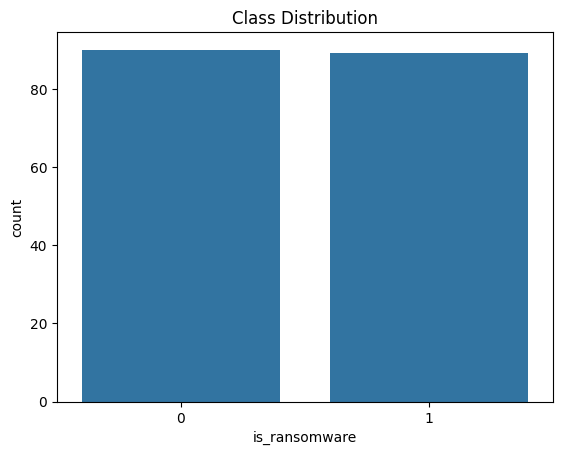

In [9]:
print(df["is_ransomware"].value_counts())

sns.countplot(x="is_ransomware", data=df)
plt.title("Class Distribution")
plt.show()


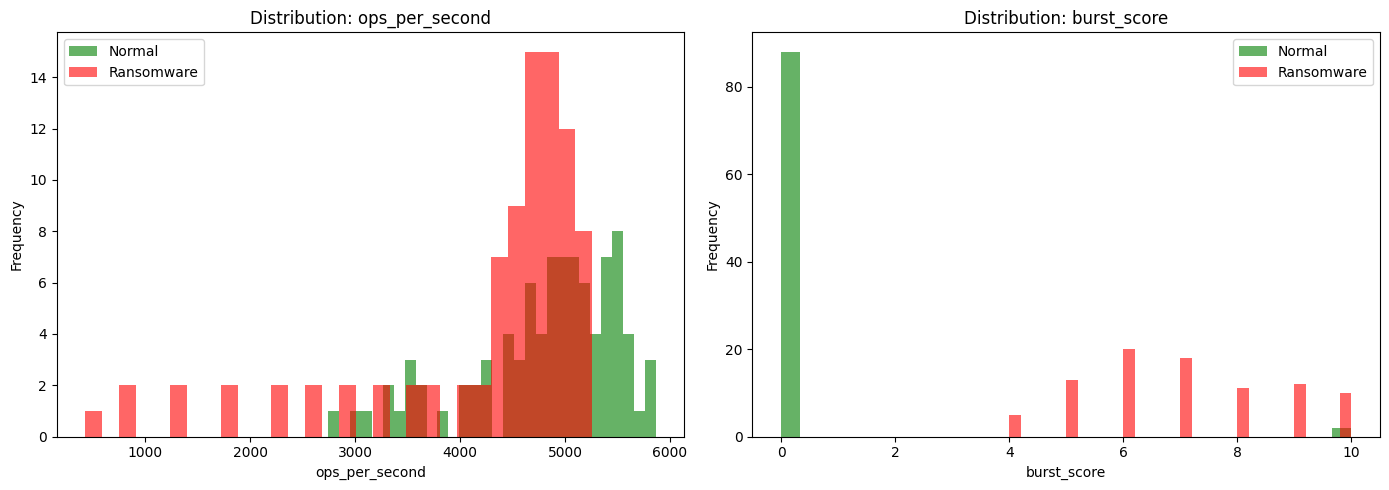

In [15]:
# Speed and burst distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['ops_per_second', 'burst_score']):
    normal = df[df['is_ransomware'] == 0][col]
    ransomware = df[df['is_ransomware'] == 1][col]
    
    ax.hist(normal, bins=30, alpha=0.6, label='Normal', color='green')
    ax.hist(ransomware, bins=30, alpha=0.6, label='Ransomware', color='red')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution: {col}')
    ax.legend()

plt.tight_layout()
plt.show()

In [11]:
X = df.drop(columns=["is_ransomware", "window_start"], errors="ignore")
y = df["is_ransomware"]

print(X.columns)


Index(['avg_entropy_1_10', 'max_entropy_1_10', 'ops_per_second',
       'bytes_per_second', 'burst_score', 'operation_count', 'total_bytes'],
      dtype='object')


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (143, 7)
Test : (36, 7)


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("scale_pos_weight:", scale_pos_weight)


scale_pos_weight: 1.0140845070422535


In [16]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb.fit(X_train_scaled, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.94      0.97        18

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



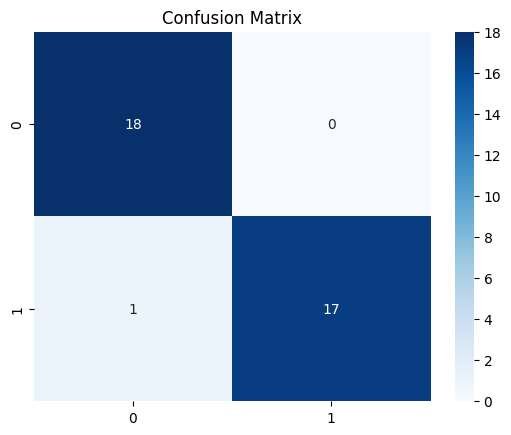

In [17]:
preds = xgb.predict(X_test_scaled)

print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


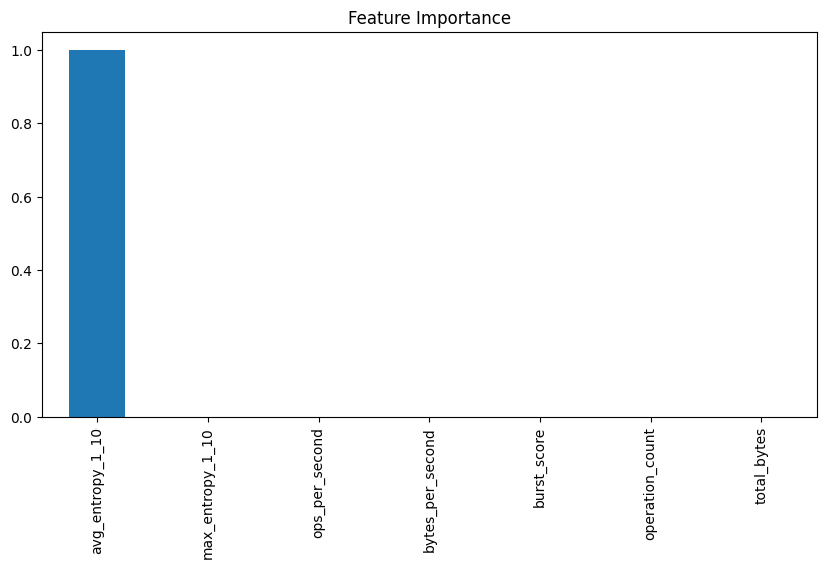

avg_entropy_1_10    1.0
max_entropy_1_10    0.0
ops_per_second      0.0
bytes_per_second    0.0
burst_score         0.0
operation_count     0.0
total_bytes         0.0
dtype: float32

In [18]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance")
plt.show()

importance


In [19]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [20]:
best_model = grid.best_estimator_
best_model.fit(X_train_scaled, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.94      0.97        18

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



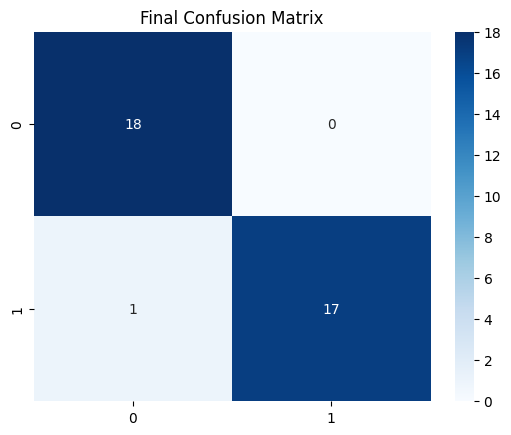

ROC-AUC: 1.0


In [21]:
final_preds = best_model.predict(X_test_scaled)

print(classification_report(y_test, final_preds))

cm = confusion_matrix(y_test, final_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Confusion Matrix")
plt.show()

roc = roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:,1])
print("ROC-AUC:", roc)


In [22]:
import joblib

joblib.dump(best_model, "ransap_xgb_model.pkl")
joblib.dump(scaler, "ransap_scaler.pkl")

print("Model saved.")


Model saved.
